# CS787 Generative AI Research Project — Week 3
## Oracle, Epsilon Target, Heterogeneity & Human Validation
**Project:** Query-Conditioned Context Allocator (QCCA) / SARA Framework  
**Benchmark:** QASPER Development Split (Paper-disjoint)  
**Scientific Objective:** Determine whether empirical query-level evidence requirements vary sufficiently across questions to justify learning a query-conditioned context allocator (QCCA).  
**Guardrail:** No QCCA training, no test set access, no expensive re-generation (100% frozen Week-2 data consumption).


## 1. Environment & Input Verification
Verify python environment, project root directory, and load configuration.


In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

# Ensure project root in sys.path
PROJECT_ROOT = Path(os.path.abspath("../.."))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(f"Working Directory: {Path.cwd()}")
print(f"Python Executable: {sys.executable}")

# Load configuration
with open("configs/week3/week3_config.yaml") as f:
    config = yaml.safe_load(f)
print("Loaded week3_config.yaml successfully.")
display(pd.DataFrame([
    {"Key": "k_sweep", "Value": str(config["k_sweep"])},
    {"Key": "k_alloc", "Value": str(config["k_alloc"])},
    {"Key": "epsilon_candidates", "Value": str(config["epsilon_candidates"])},
    {"Key": "human_audit_sample", "Value": str(config["human_audit"]["n_questions"])},
    {"Key": "random_seed", "Value": str(config["seed"])}
]))


Working Directory: /home/gunavenkat/Downloads/CS787-RAG-Project
Python Executable: /home/gunavenkat/sara_env/bin/python
Loaded week3_config.yaml successfully.


,Key,Value
0,k_sweep,"[0, 2, 4, 5, 6, 8, 10]"
1,k_alloc,"[2, 4, 5, 6, 8]"
2,epsilon_candidates,"[0.0, 0.01, 0.02, 0.05]"
3,human_audit_sample,50
4,random_seed,42


## 2. Load Frozen Week-2 Results & Data Integrity Checks
Verify that all 231 development questions across 86 papers are intact with all 7 $k$ conditions ($231 \times 7 = 1,617$ records).


In [2]:
from src.week3.oracle_analysis import load_raw_dev_matrix, load_best_static_baseline

raw_matrix_path = config["paths"]["week2_raw_matrix"]
df_raw = load_raw_dev_matrix(raw_matrix_path)
best_static = load_best_static_baseline(config["paths"]["week2_best_static"])

n_q = df_raw["question_id"].nunique()
n_p = df_raw["paper_id"].nunique()
n_rec = len(df_raw)
k_vals = sorted(df_raw["k"].unique().tolist())
dups = df_raw.duplicated(subset=["question_id", "k"]).sum()
null_f1 = df_raw["token_f1"].isna().sum()

integrity_summary = pd.DataFrame([{
    "Metric": "Total Records", "Expected": 1617, "Actual": n_rec, "Status": "PASS" if n_rec == 1617 else "FAIL"
}, {
    "Metric": "Unique Questions", "Expected": 231, "Actual": n_q, "Status": "PASS" if n_q == 231 else "FAIL"
}, {
    "Metric": "Unique Papers", "Expected": 86, "Actual": n_p, "Status": "PASS" if n_p == 86 else "FAIL"
}, {
    "Metric": "Present k values", "Expected": "[0, 2, 4, 5, 6, 8, 10]", "Actual": str(k_vals), "Status": "PASS"
}, {
    "Metric": "Duplicate (q, k) pairs", "Expected": 0, "Actual": dups, "Status": "PASS" if dups == 0 else "FAIL"
}, {
    "Metric": "Null / NaN Token F1", "Expected": 0, "Actual": null_f1, "Status": "PASS" if null_f1 == 0 else "FAIL"
}])
display(integrity_summary)

print(f"Static SARA Baseline: k={best_static['best_static_sara_k']}, Mean F1={best_static['sara_k8_mean_f1']:.4f}")
print(f"Standard RAG Reference: k={best_static['best_overall_fixed_k']}, Mean F1={best_static['vanilla_rag_k10_f1']:.4f}")


,Metric,Expected,Actual,Status
0,Total Records,1617,1617,PASS
1,Unique Questions,231,231,PASS
2,Unique Papers,86,86,PASS
3,Present k values,"[0, 2, 4, 5, 6, 8, 10]","[0, 2, 4, 5, 6, 8, 10]",PASS
4,"Duplicate (q, k) pairs",0,0,PASS
5,Null / NaN Token F1,0,0,PASS


Static SARA Baseline: k=8, Mean F1=0.3950
Standard RAG Reference: k=10, Mean F1=0.4090


## 3. Methodological Audit: Dual Oracle Definitions
Inspect the methodology audit document detailing the distinction between deployable SARA actions $\mathcal{K}_{\text{alloc}} = \{2, 4, 5, 6, 8\}$ and diagnostic sweep reference $\mathcal{K}_{\text{sweep}} = \{0, 2, 4, 5, 6, 8, 10\}$.


In [3]:
with open("results/week3/processed/methodology_audit.md") as f:
    audit_text = f.read()
# Display first 2 sections
display(Markdown("\n".join(audit_text.split("\n")[:35])))


# Methodological Audit: Dual Oracle Definitions & Epsilon Target Formulation

**Project:** Query-Conditioned Context Allocator (QCCA)  
**Parent Framework:** SARA (Selective and Adaptive Retrieval-augmented Generation with Context Compression)  
**Phase:** Week 3 (Oracle, Epsilon Target, Heterogeneity & Human Validation)  
**Date:** 2026-09-30  
**Status:** Methodological Clarification & Refinement Documented and Locked

---

## 1. Background & The Original Plan v2.1 Formulation

In *Plan v2.1* (Section 4.1, Equation 365), the epsilon-constrained optimal evidence budget was formally defined as:
$$k^*_\epsilon(q) = \min \left\{ k \in \mathcal{K}_{\text{alloc}} \;\Big|\; \text{F1}(q, k) \ge \max_{j \in \mathcal{K}_{\text{sweep}}} \text{F1}(q, j) - \epsilon \right\}$$
where:
$$\mathcal{K}_{\text{sweep}} = \{0, 2, 4, 5, 6, 8, 10\}$$
$$\mathcal{K}_{\text{alloc}} = \{2, 4, 5, 6, 8\}$$

The intent of this formulation was to identify the minimum acceptable evidence budget $k \in \mathcal{K}_{\text{alloc}}$ that retains performance within a margin $\epsilon$ of the best achievable quality across all empirical conditions.

---

## 2. Identified Methodological Inconsistency

During the empirical pre-flight audit of the frozen Week-2 fixed-$k$ response matrix ($N = 231$ questions across 86 papers), an asymmetry between the reference space ($\mathcal{K}_{\text{sweep}}$) and the target action space ($\mathcal{K}_{\text{alloc}}$) was identified:

1. **Model & Checkpoint Heterogeneity ($k=10$):**
   - Condition $k=10$ represents uncompressed **Standard RAG** using full natural-language context and a dedicated RAG LoRA checkpoint (`rag_qasper_lora_r16_seed42`).
   - Conditions $k \in \{2, 4, 5, 6, 8\}$ represent deployable **SARA** configurations using the SARA context compressor and trained projector (`sara_qasper_proj_lr5e4_seed42`).
   - Consequently, $k=10$ is not a valid operational state of the SARA projector; it is an external ceiling benchmark.

2. **The Infeasibility Dilemma:**
   - When evaluating $\max_{j \in \mathcal{K}_{\text{sweep}}} \text{F1}(q, j)$ as the reference quality, for **31 out of 231 questions (13.42%)**, the global maximum occurs strictly outside $\mathcal{K}_{\text{alloc}}$:
     - For **20 questions**, Standard RAG ($k=10$) uniquely outperforms all SARA configurations.
     - For **14 questions**, Pure Compression ($k=0$) uniquely outperforms all $k \ge 2$ configurations (e.g., short abstractive queries where retrieved passages induce distraction).

## 4. Quality Oracle & Headroom Analysis
Evaluate the primary Quality Oracle:
$$k^*_{\text{qual}}(q) = \arg\max_{k \in \mathcal{K}_{\text{alloc}}} \text{F1}(q, k) \quad \text{(ties broken to smallest } k\text{)}$$
Compare against best static SARA baseline ($k=8$) to quantify empirical adaptation headroom.


In [4]:
from src.week3.oracle_analysis import run_oracle_analysis

oracle_summary = run_oracle_analysis(
    config["paths"]["week2_raw_matrix"],
    config["paths"]["week2_best_static"],
    "results/week3/processed"
)

df_oracle = pd.read_csv("results/week3/processed/dev_quality_oracle.csv")
print("Top 5 Dev Quality Oracle Records:")
display(df_oracle[["question_id", "paper_id", "best_k_qual", "best_f1_qual", "best_static_k", "best_static_f1", "oracle_gain"]].head())

headroom_df = pd.DataFrame([oracle_summary["headroom"]])
print("\nOracle Quality Headroom Summary:")
display(headroom_df)


2026-09-30 17:29:37,983 [INFO] Loading raw fixed-k matrix from results/week2/raw/dev_fixed_k_matrix.jsonl


2026-09-30 17:29:38,012 [INFO] Loading best static baseline from results/week2/processed/best_static_baseline.json


2026-09-30 17:29:38,013 [INFO] Pivoting per-query matrix across K_sweep


2026-09-30 17:29:38,018 [INFO] Computing primary Quality Oracle over K_alloc = [2, 4, 5, 6, 8]


2026-09-30 17:29:38,034 [INFO] Saved quality oracle records to results/week3/processed/dev_quality_oracle.csv


...

2026-09-30 17:29:38,058 [INFO] Diagnostic RAG ceiling gap: k=10 wins in 20 queries (8.66%)


Top 5 Dev Quality Oracle Records:


,question_id,paper_id,best_k_qual,best_f1_qual,best_static_k,best_static_f1,oracle_gain
0,1000,293,4,1.0000,8,1.0000,0.0000
1,1001,293,6,0.6000,8,0.4167,0.1833
2,1002,293,5,0.2105,8,0.2105,0.0000
3,1003,293,2,0.0000,8,0.0000,0.0000
4,1004,294,5,0.8889,8,0.0000,0.8889



Oracle Quality Headroom Summary:


,mean_oracle_f1,mean_best_static_f1,absolute_headroom,relative_headroom_pct,oracle_static_ratio,n_questions
0,0.4895,0.395,0.0945,23.93,1.2393,231


## 5. Optimal Evidence Budget Distribution & Gain Attribution
Analyze the frequency and cumulative distribution of optimal evidence budgets across development queries, and the attribution of total oracle headroom.


Quality Oracle Best-k Distribution:


,k,count,pct,cumulative_count,cumulative_pct
0,2,130,56.28,130,56.28
1,4,40,17.32,170,73.59
2,5,17,7.36,187,80.95
3,6,21,9.09,208,90.04
4,8,23,9.96,231,100.00



Headroom Gain Attribution by Optimal Budget:


,best_k_qual,question_count,total_gain,mean_gain_per_question,pct_of_total_gain
0,2,130,8.3497,0.0642,38.24
1,4,40,6.4757,0.1619,29.66
2,5,17,3.4256,0.2015,15.69
3,6,21,3.5813,0.1705,16.40
4,8,23,0.0000,0.0000,0.00


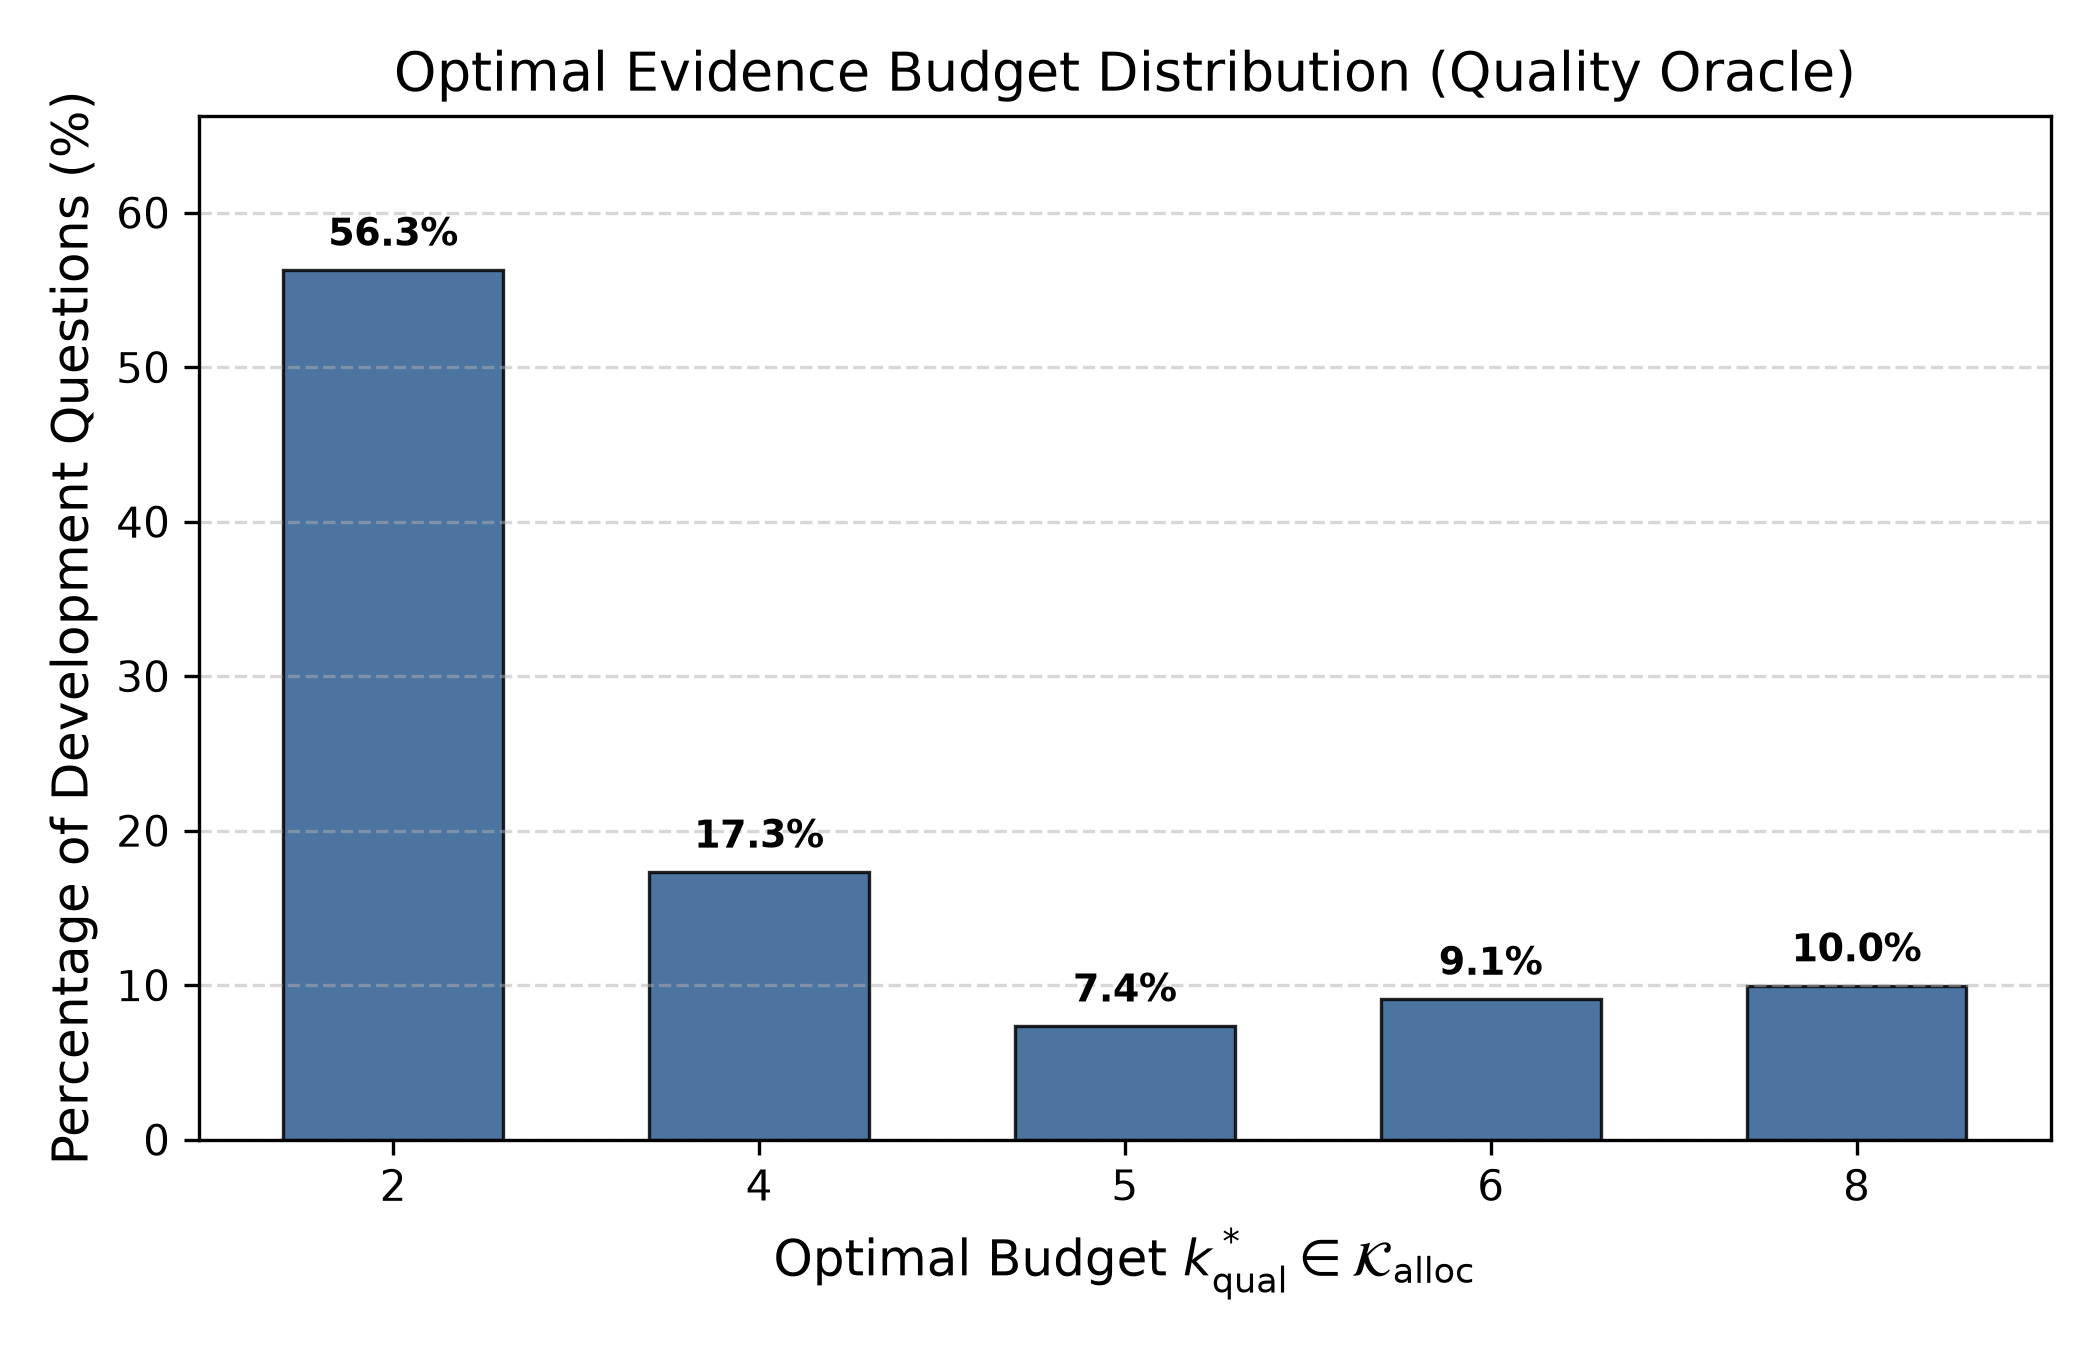

In [5]:
df_dist = pd.read_csv("results/week3/processed/quality_oracle_distribution.csv")
print("Quality Oracle Best-k Distribution:")
display(df_dist)

df_gain_attr = pd.read_csv("results/week3/processed/oracle_gain_attribution.csv")
print("\nHeadroom Gain Attribution by Optimal Budget:")
display(df_gain_attr)

# Display Plot 1
display(Image("results/week3/plots/plot1_best_k_distribution.png"))


## 6. Tie Analysis & Sensitivity
Quantify the degree of exact and near ties across $\mathcal{K}_{\text{alloc}}$ to confirm that smallest-$k$ tie breaking is strictly deterministic.


In [6]:
df_ties = pd.read_csv("results/week3/processed/tie_analysis.csv")
tie_counts = df_ties["n_tied_k"].value_counts().sort_index().rename("Question Count").to_frame()
tie_counts["Percentage (%)"] = (tie_counts["Question Count"] / len(df_ties) * 100).round(2)
display(tie_counts)

print(f"Strict unique winner: {(df_ties['n_tied_k'] == 1).sum()} queries")
print(f"All-zero tie (unanswerable floor): {df_ties['is_all_zero_tie'].sum()} queries")


,Question Count,Percentage (%)
n_tied_k,,
1,72,31.17
2,25,10.82
3,13,5.63
4,24,10.39
5,97,41.99


Strict unique winner: 72 queries
All-zero tie (unanswerable floor): 52 queries


## 7. Per-Query Heterogeneity & Adaptation Opportunity
Measure evidence sensitivity ranges $(\max F1 - \min F1)$, agreement with static allocation, and compute paper-clustered bootstrap confidence intervals ($B=1000$).
Includes a separate tie-aware analysis to distinguish strict adaptation opportunities from smallest-$k$ tie breaking.


2026-09-30 17:29:38,207 [INFO] Saved per-query heterogeneity to results/week3/processed/per_query_heterogeneity.csv


2026-09-30 17:29:38,211 [INFO] Computing paper-clustered bootstrap CIs (B=1000)...


2026-09-30 17:29:42,198 [INFO] Saved edge cases catalog to results/week3/processed/edge_cases.json


2026-09-30 17:29:42,199 [INFO] Saved heterogeneity summary to results/week3/processed/heterogeneity_summary.json


F1 Range & Oracle Gain Statistics:


...

,strict_gain_gt_00_pct,strict_gain_gt_01_pct,strict_gain_gt_02_pct,strict_gain_gt_05_pct,strict_gain_gt_10_pct
0,29.44,29.0,29.0,26.84,23.81



Strict Unique Winners Breakdown (31.17% of queries):


,2,4,5,6,8
0,17,12,7,13,23



Paper-Clustered Bootstrap 95% Confidence Intervals:


,mean,ci_lower,ci_upper,n_clusters
mean_oracle_f1,0.4904,0.4399,0.5454,86
mean_static_f1,0.3958,0.3469,0.4528,86
oracle_headroom,0.0945,0.0693,0.1226,86
mean_f1_range,0.2473,0.2073,0.2895,86
pct_questions_gain_gt_00,29.5004,23.8734,35.2967,86
pct_questions_gain_gt_01,29.0815,23.635,34.8184,86
pct_questions_gain_gt_02,29.0815,23.635,34.8184,86
pct_questions_gain_gt_05,26.9096,21.6192,32.3702,86


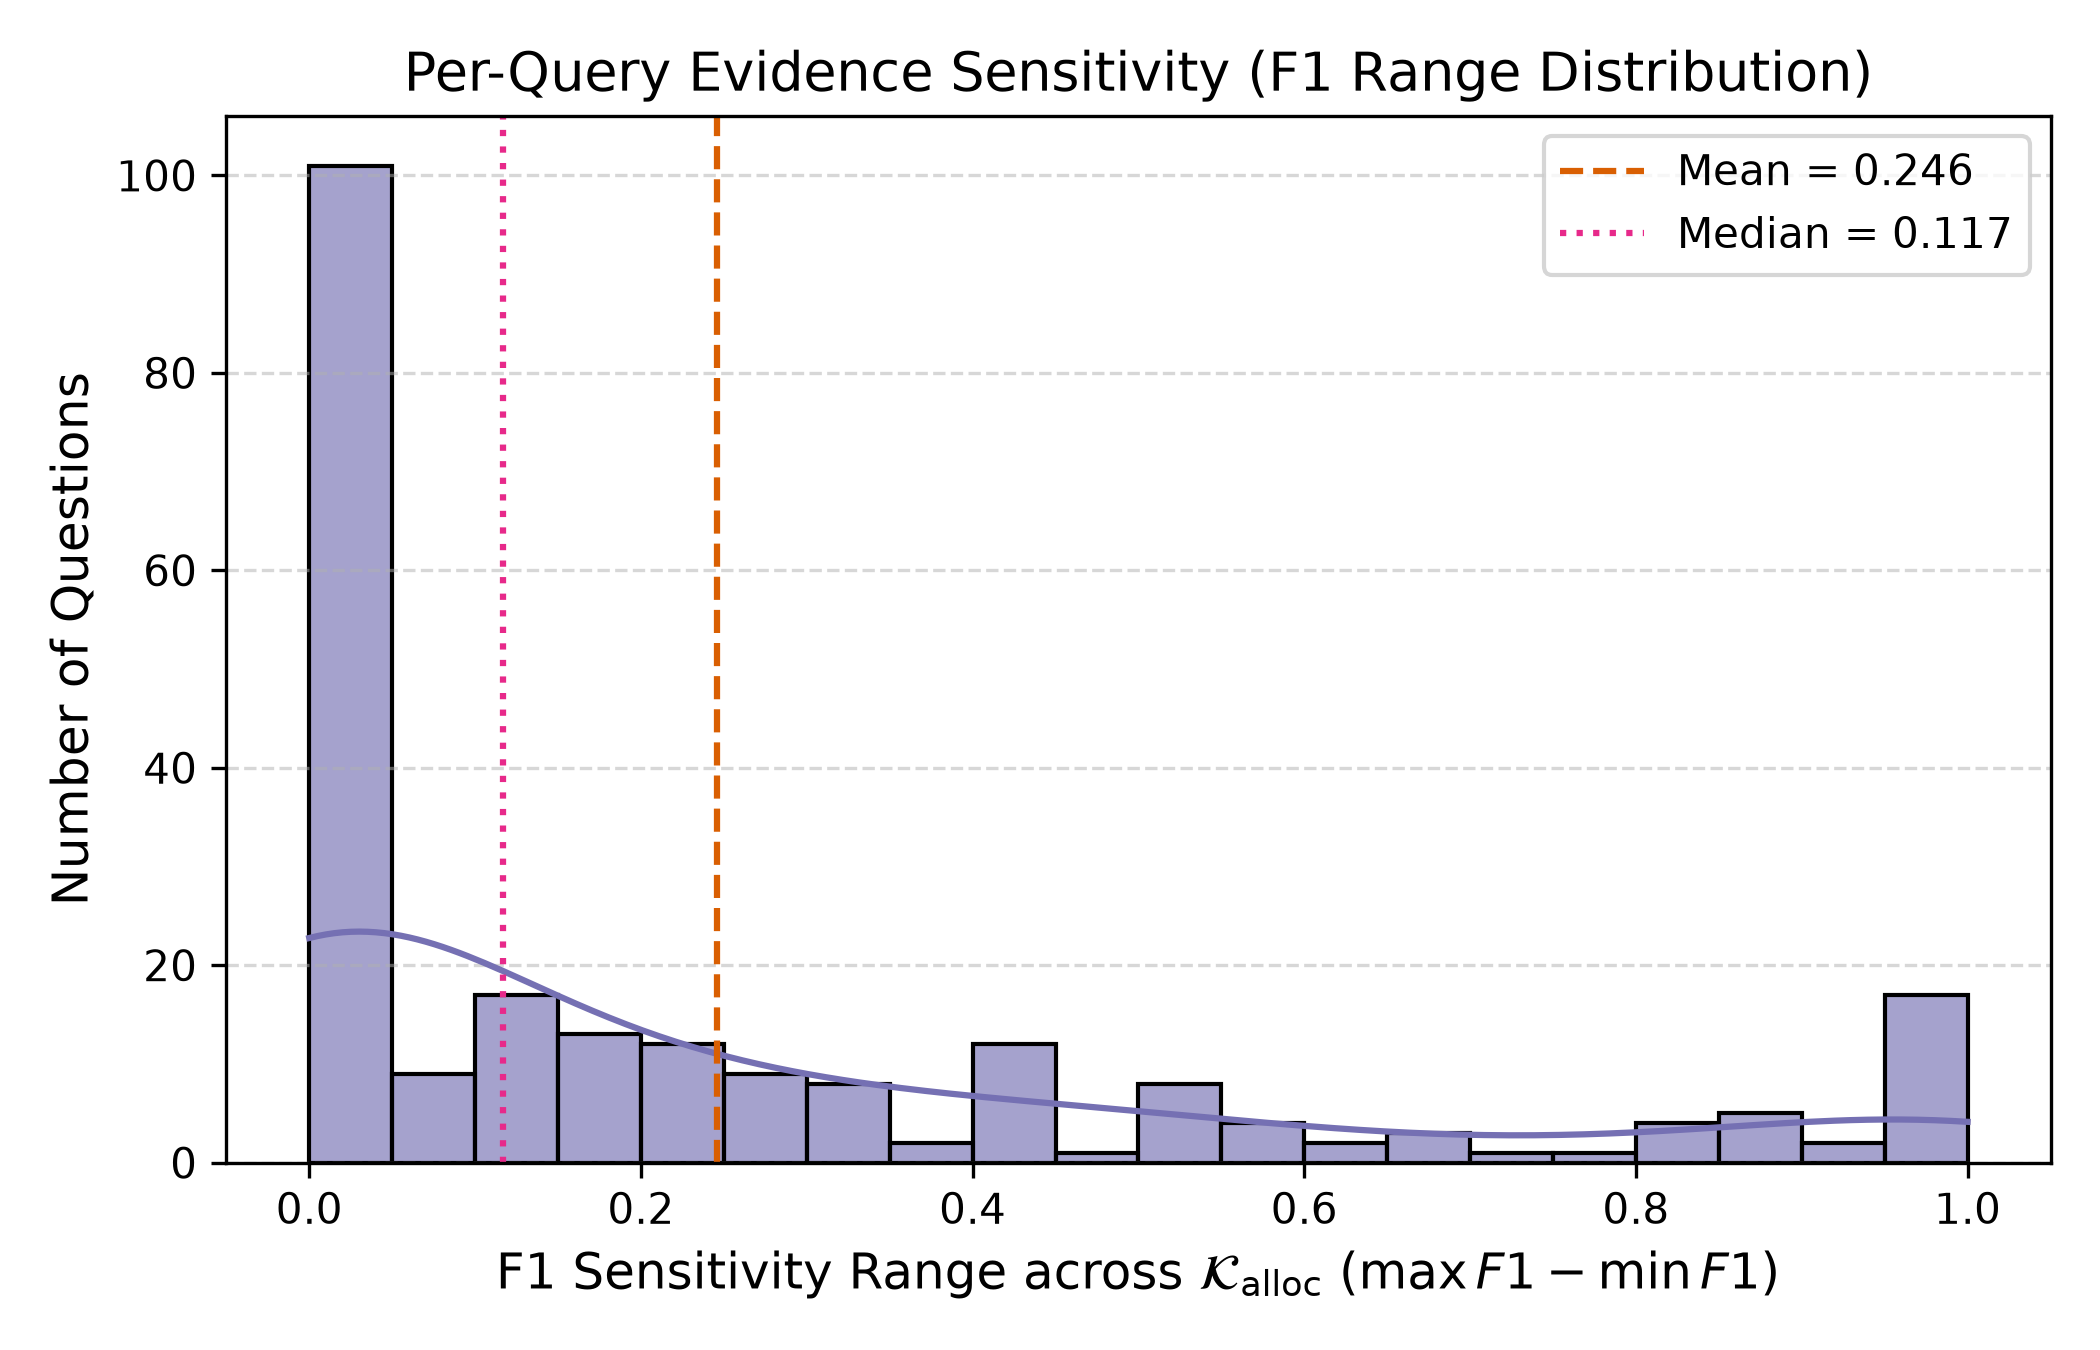

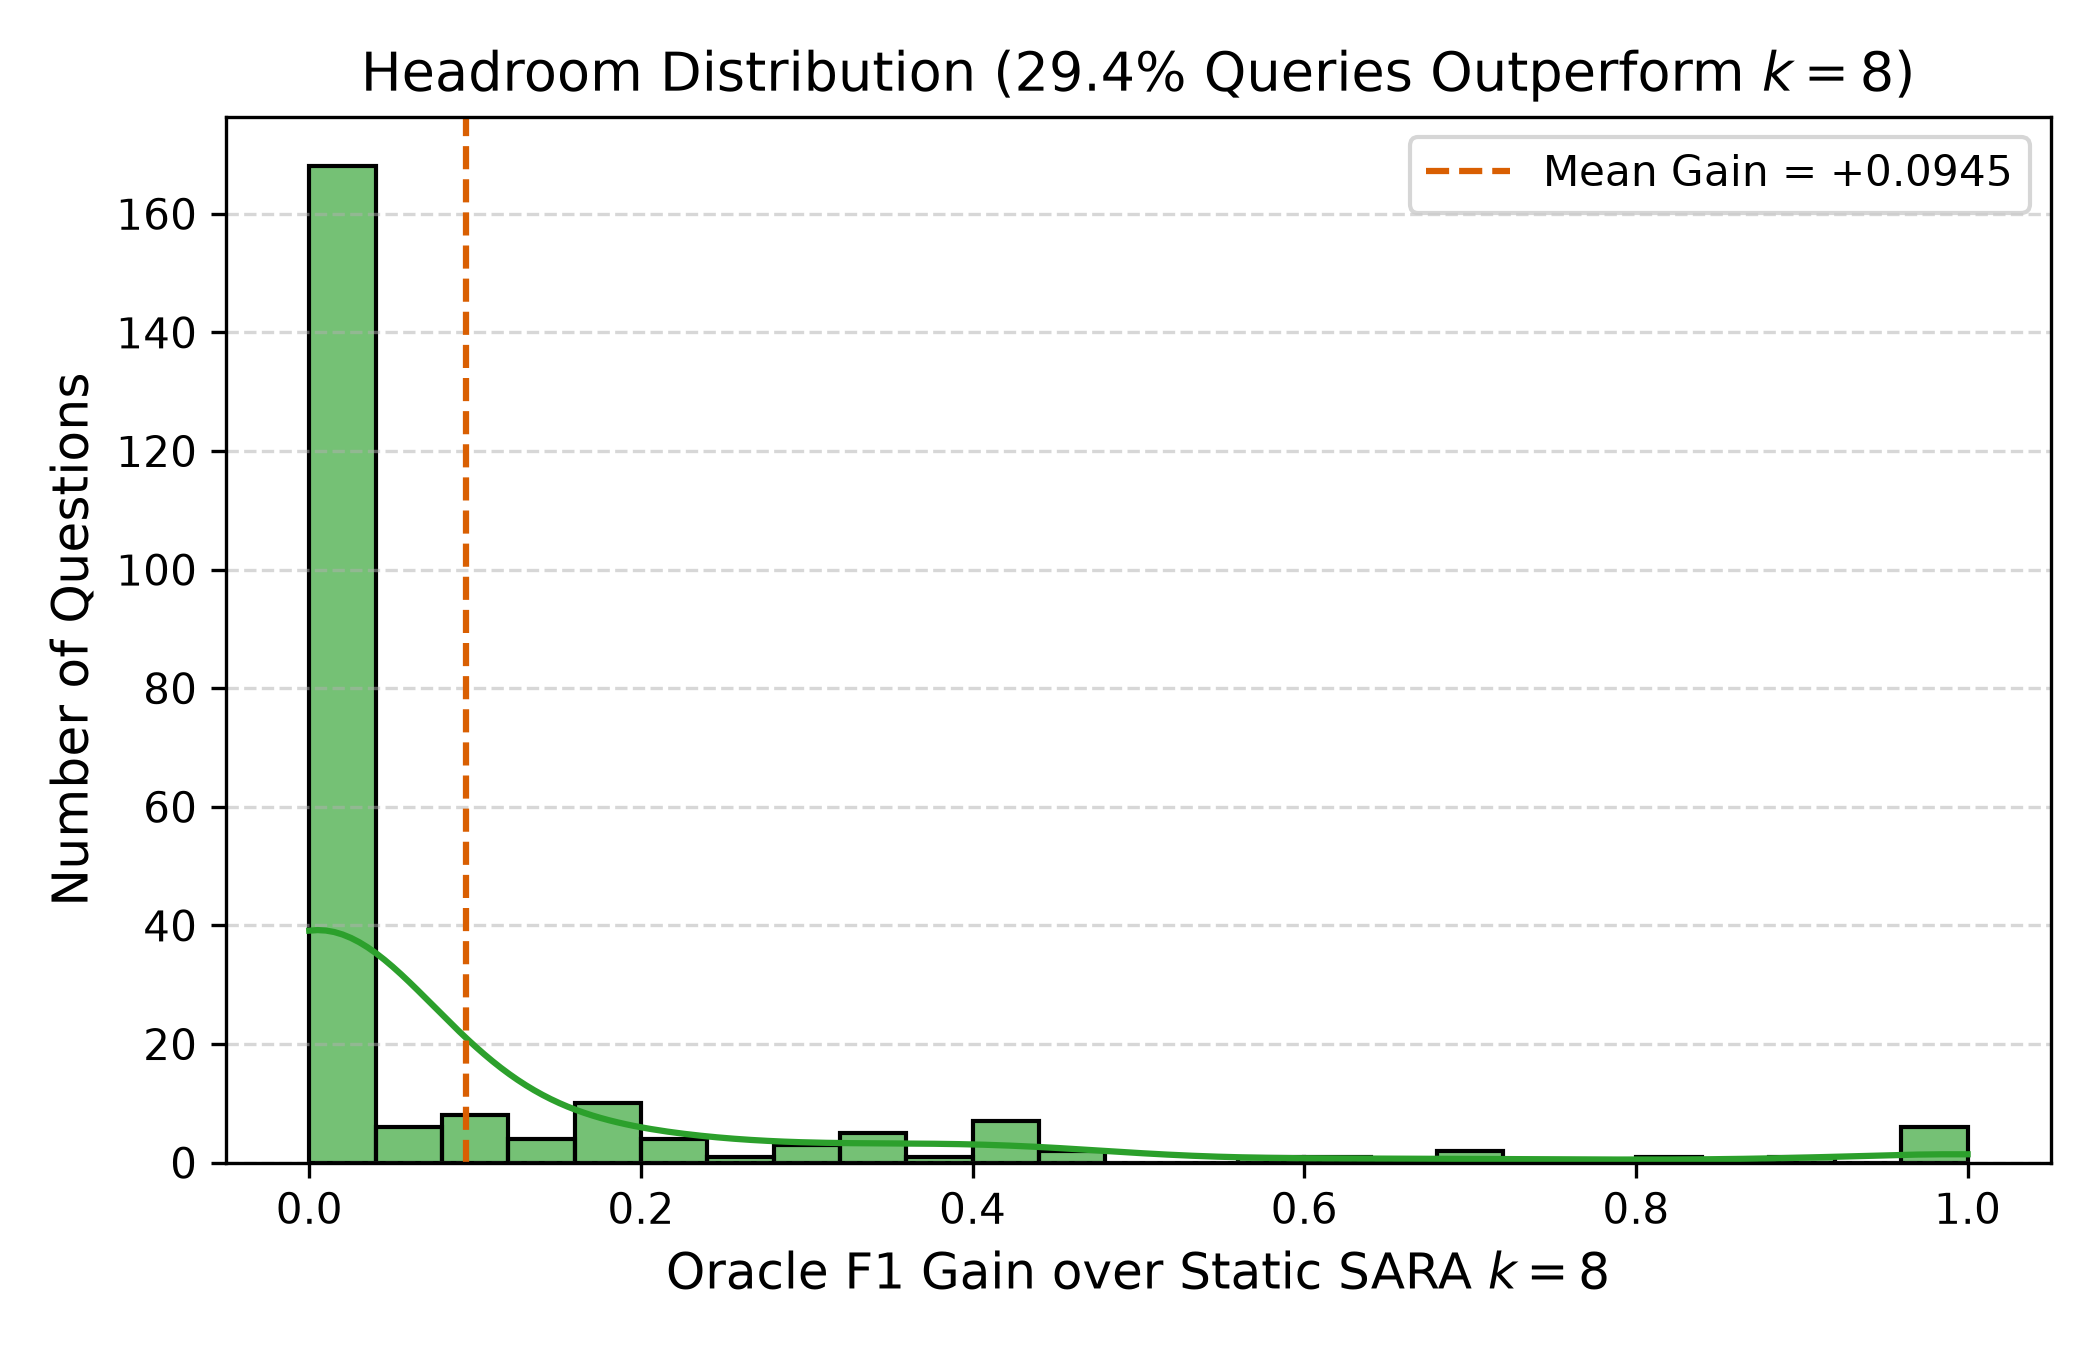

In [7]:
from src.week3.heterogeneity_analysis import run_heterogeneity_analysis

df_het, het_sum, edge_cases = run_heterogeneity_analysis(
    config["paths"]["week2_raw_matrix"],
    config["paths"]["week2_best_static"],
    "results/week3/processed"
)

# Display Descriptive Statistics
print("F1 Range & Oracle Gain Statistics:")
stats_df = pd.DataFrame([
    {"Metric": "F1 Sensitivity Range", **het_sum["f1_range_statistics"]},
    {"Metric": "Oracle Gain over k=8", **het_sum["oracle_gain_statistics"]}
])
display(stats_df)

print("\nTie-Aware Static k=8 Status Breakdown:")
display(pd.DataFrame([het_sum["tie_aware_k8_status"]]))

print("\nStrict Adaptation Opportunities (Strict Gain over k=8):")
display(pd.DataFrame([het_sum["strict_adaptation_opportunity"]]))

print(f"\nStrict Unique Winners Breakdown ({het_sum['strict_winner_analysis']['total_strict_winners_pct']}% of queries):")
display(pd.DataFrame([het_sum["strict_winner_analysis"]["strict_winners_by_budget"]]))

print("\nPaper-Clustered Bootstrap 95% Confidence Intervals:")
boot_df = pd.DataFrame(het_sum["paper_clustered_bootstrap_cis"]).T
display(boot_df[["mean", "ci_lower", "ci_upper", "n_clusters"]])

# Display Plots 2 & 3
display(Image("results/week3/plots/plot2_f1_range_distribution.png"))
display(Image("results/week3/plots/plot3_oracle_gain_distribution.png"))


## 8. Epsilon Oracle & Freezing $\epsilon^*$
Evaluate the primary SARA-internal epsilon target across candidate $\epsilon \in \{0.00, 0.01, 0.02, 0.05\}$:
$$k^*_\epsilon(q) = \min \{ k \in \mathcal{K}_{\text{alloc}} \mid \text{F1}(q, k) \ge F1^*_{\text{alloc}}(q) - \epsilon \}$$


2026-09-30 17:29:42,308 [INFO] Saved all epsilon records to results/week3/processed/epsilon_oracle_all.csv


2026-09-30 17:29:42,309 [INFO] Saved epsilon summary to results/week3/processed/epsilon_summary.csv


2026-09-30 17:29:42,310 [INFO] Saved selected epsilon* metadata to results/week3/processed/selected_epsilon.json: eps*=0.01


Epsilon Target Sweep Summary:


,epsilon,mean_k,median_k,mean_f1,mean_regret,max_regret,p95_regret,mean_context_tokens,context_reduction_pct_vs_k8,context_reduction_pct_vs_k10,feasibility_pct_sara,pct_k2,pct_k4,pct_k5,pct_k6,pct_k8,diag_sweep_feasibility_pct
0,0.00,3.53,2,0.4895,0.0000,0.0000,0.0,848.4,51.75,60.32,100.0,56.28,17.32,7.36,9.09,9.96,86.58
1,0.01,3.49,2,0.4894,0.0001,0.0095,0.0,841.3,52.16,60.65,100.0,57.14,17.32,7.36,8.23,9.96,86.58
2,0.02,3.45,2,0.4892,0.0003,0.0200,0.0,831.6,52.71,61.10,100.0,58.01,17.32,6.93,8.66,9.09,87.01
3,0.05,3.43,2,0.4888,0.0007,0.0500,0.0,828.0,52.91,61.27,100.0,58.44,16.88,6.93,9.09,8.66,88.31



Frozen Epsilon* Selection: epsilon* = 0.01
Selection Rule: Selected conservative operational tolerance that introduces negligible mean regret relative to the deployable quality oracle while modestly reducing the selected evidence budget and retaining substantial representation across non-minimum budgets. The choice is made entirely from development-set oracle statistics and is independent of downstream allocator performance.
Rationale: epsilon*=0.01 was selected as a conservative operational tolerance because it introduces negligible mean regret (0.0001) relative to the deployable quality oracle while modestly reducing the selected evidence budget (mean k=3.49 vs static k=8, a 52.16% context reduction: 841.3 vs 1758.5 tokens) and retaining substantial representation across non-minimum budgets (42.86% requiring k in {4,5,6,8}). The choice is made entirely from development-set oracle statistics and is independent of downstream allocator performance.


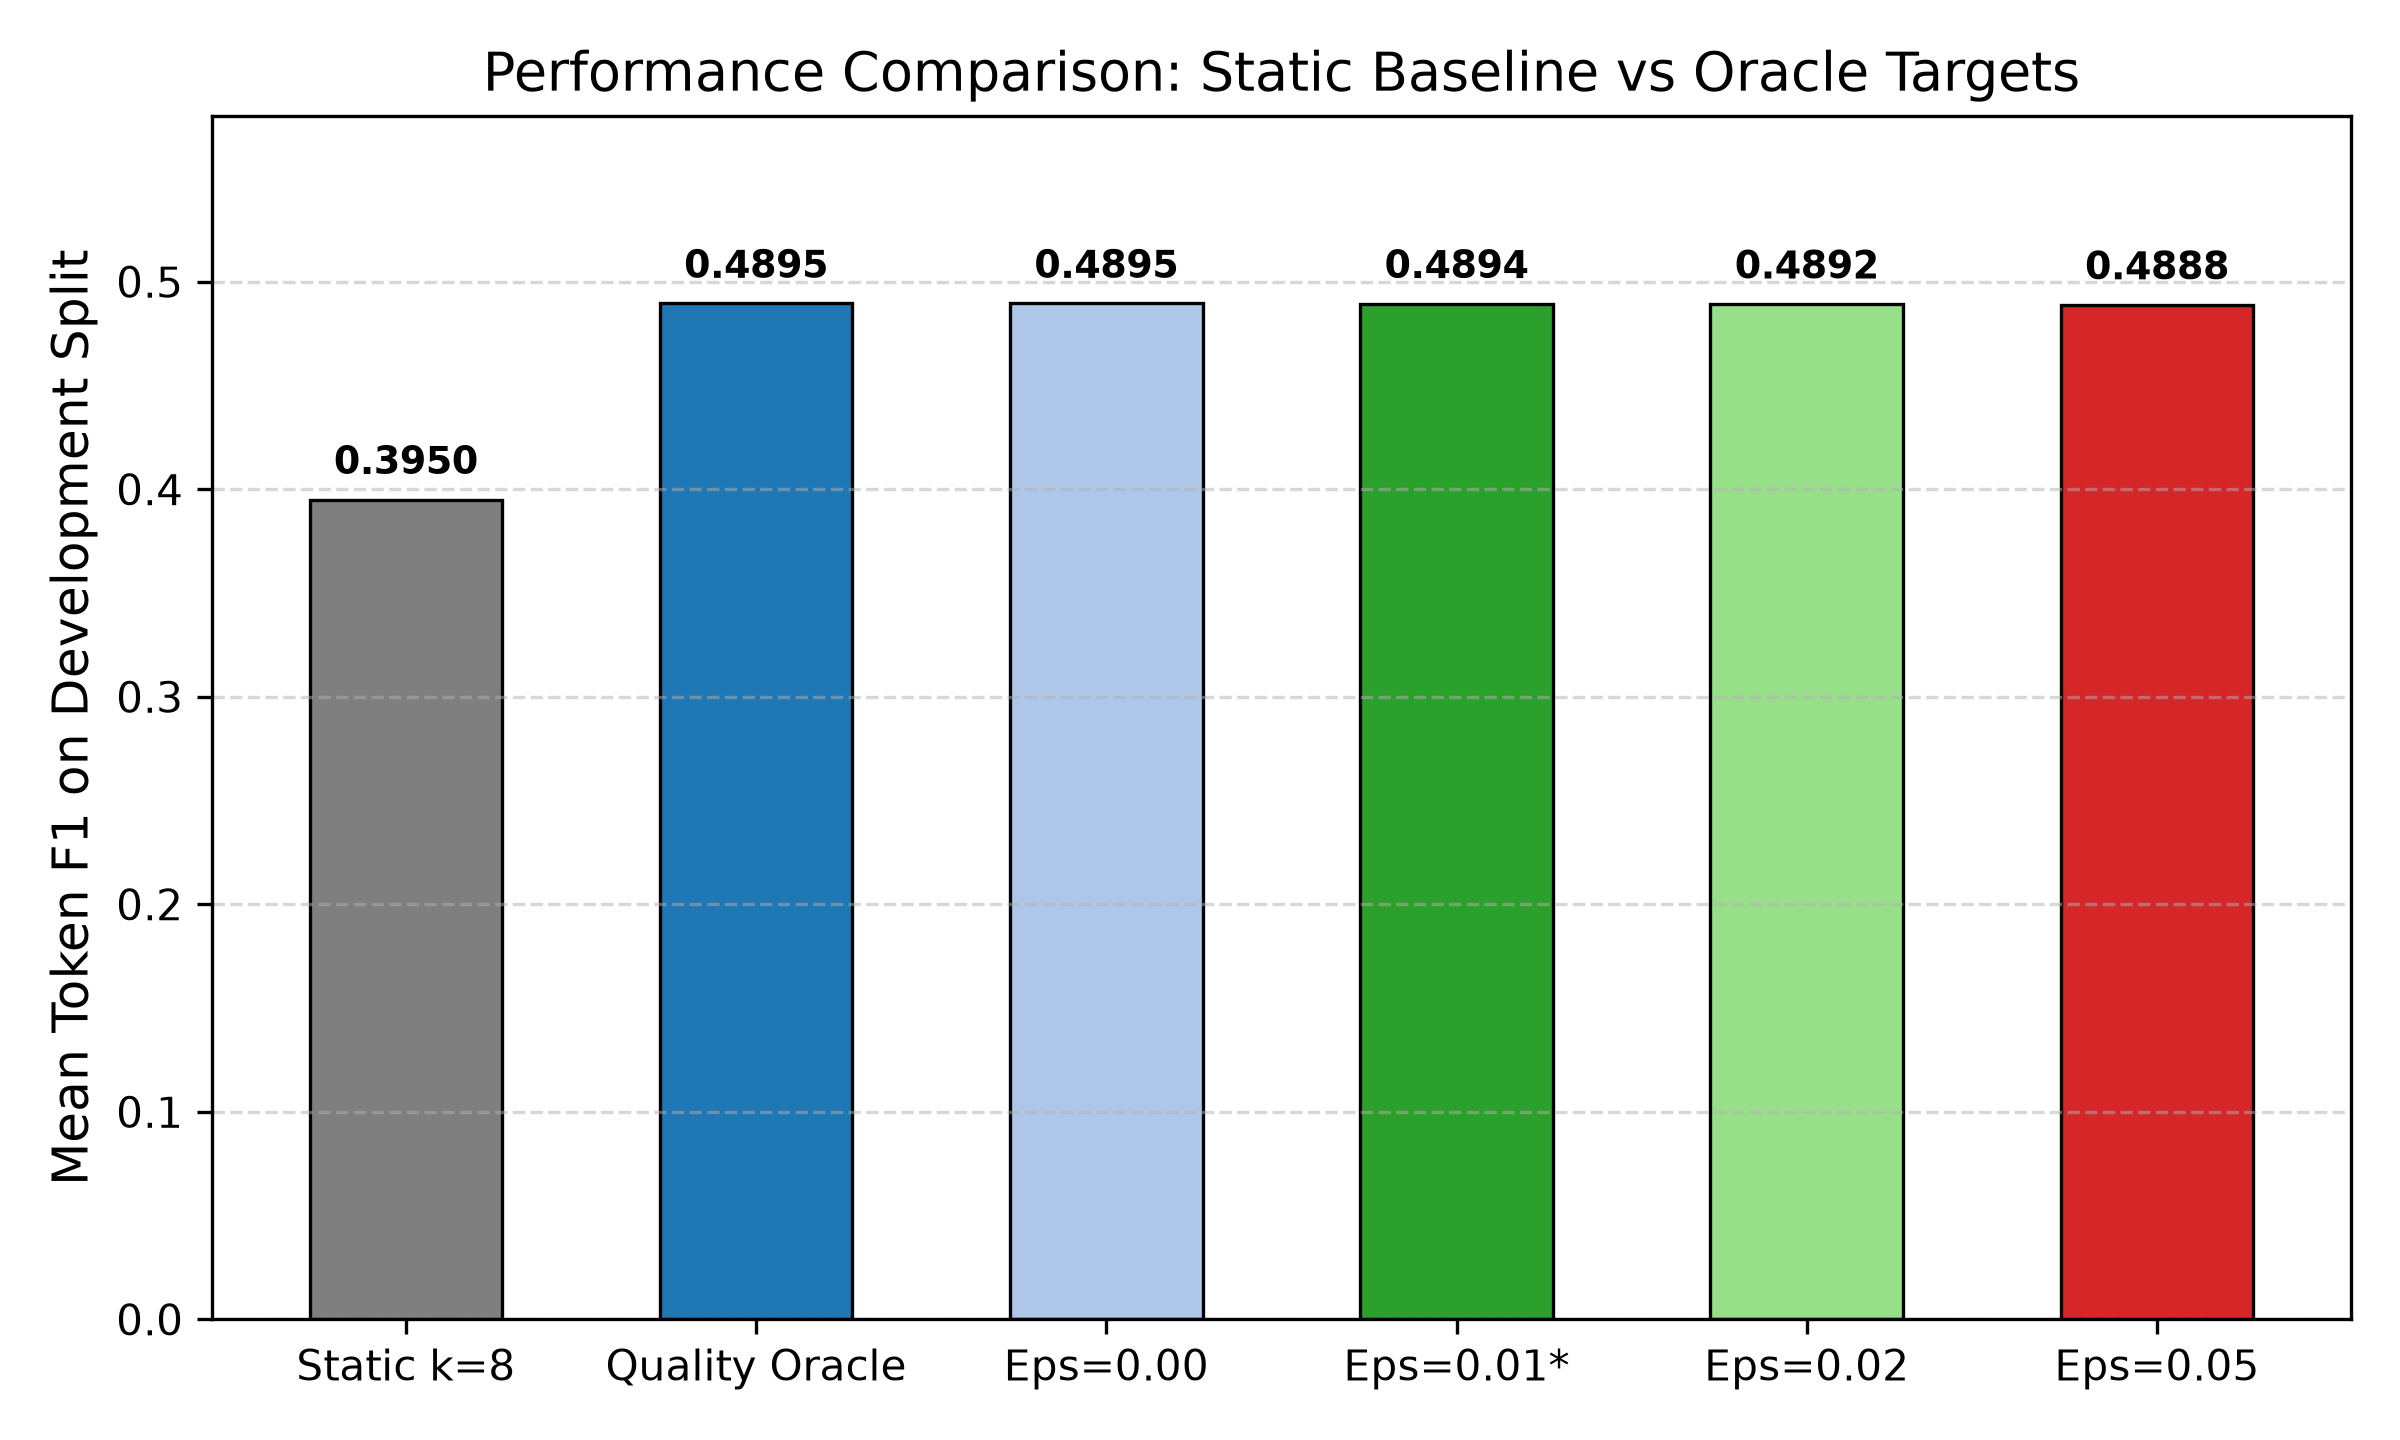

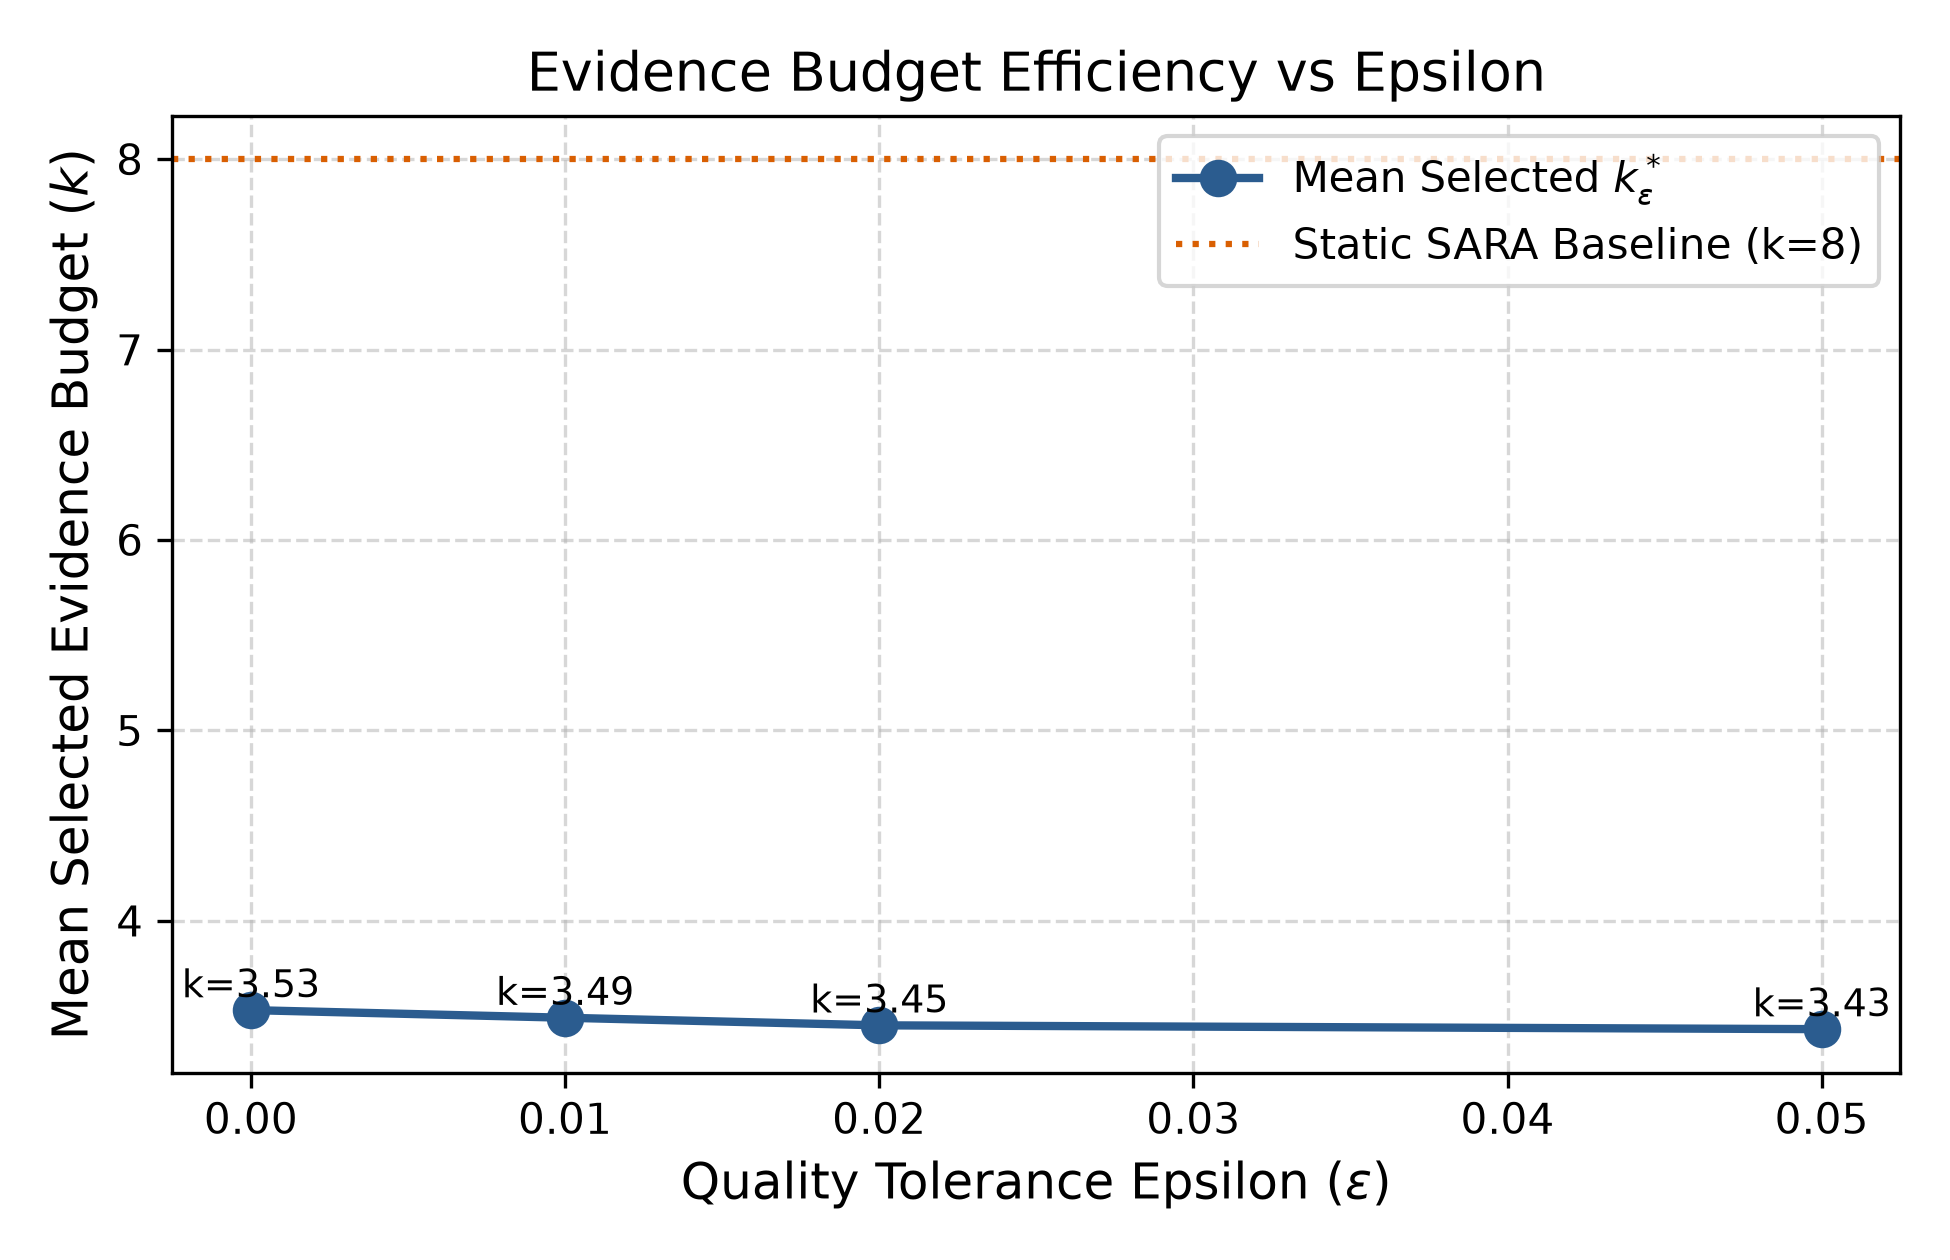

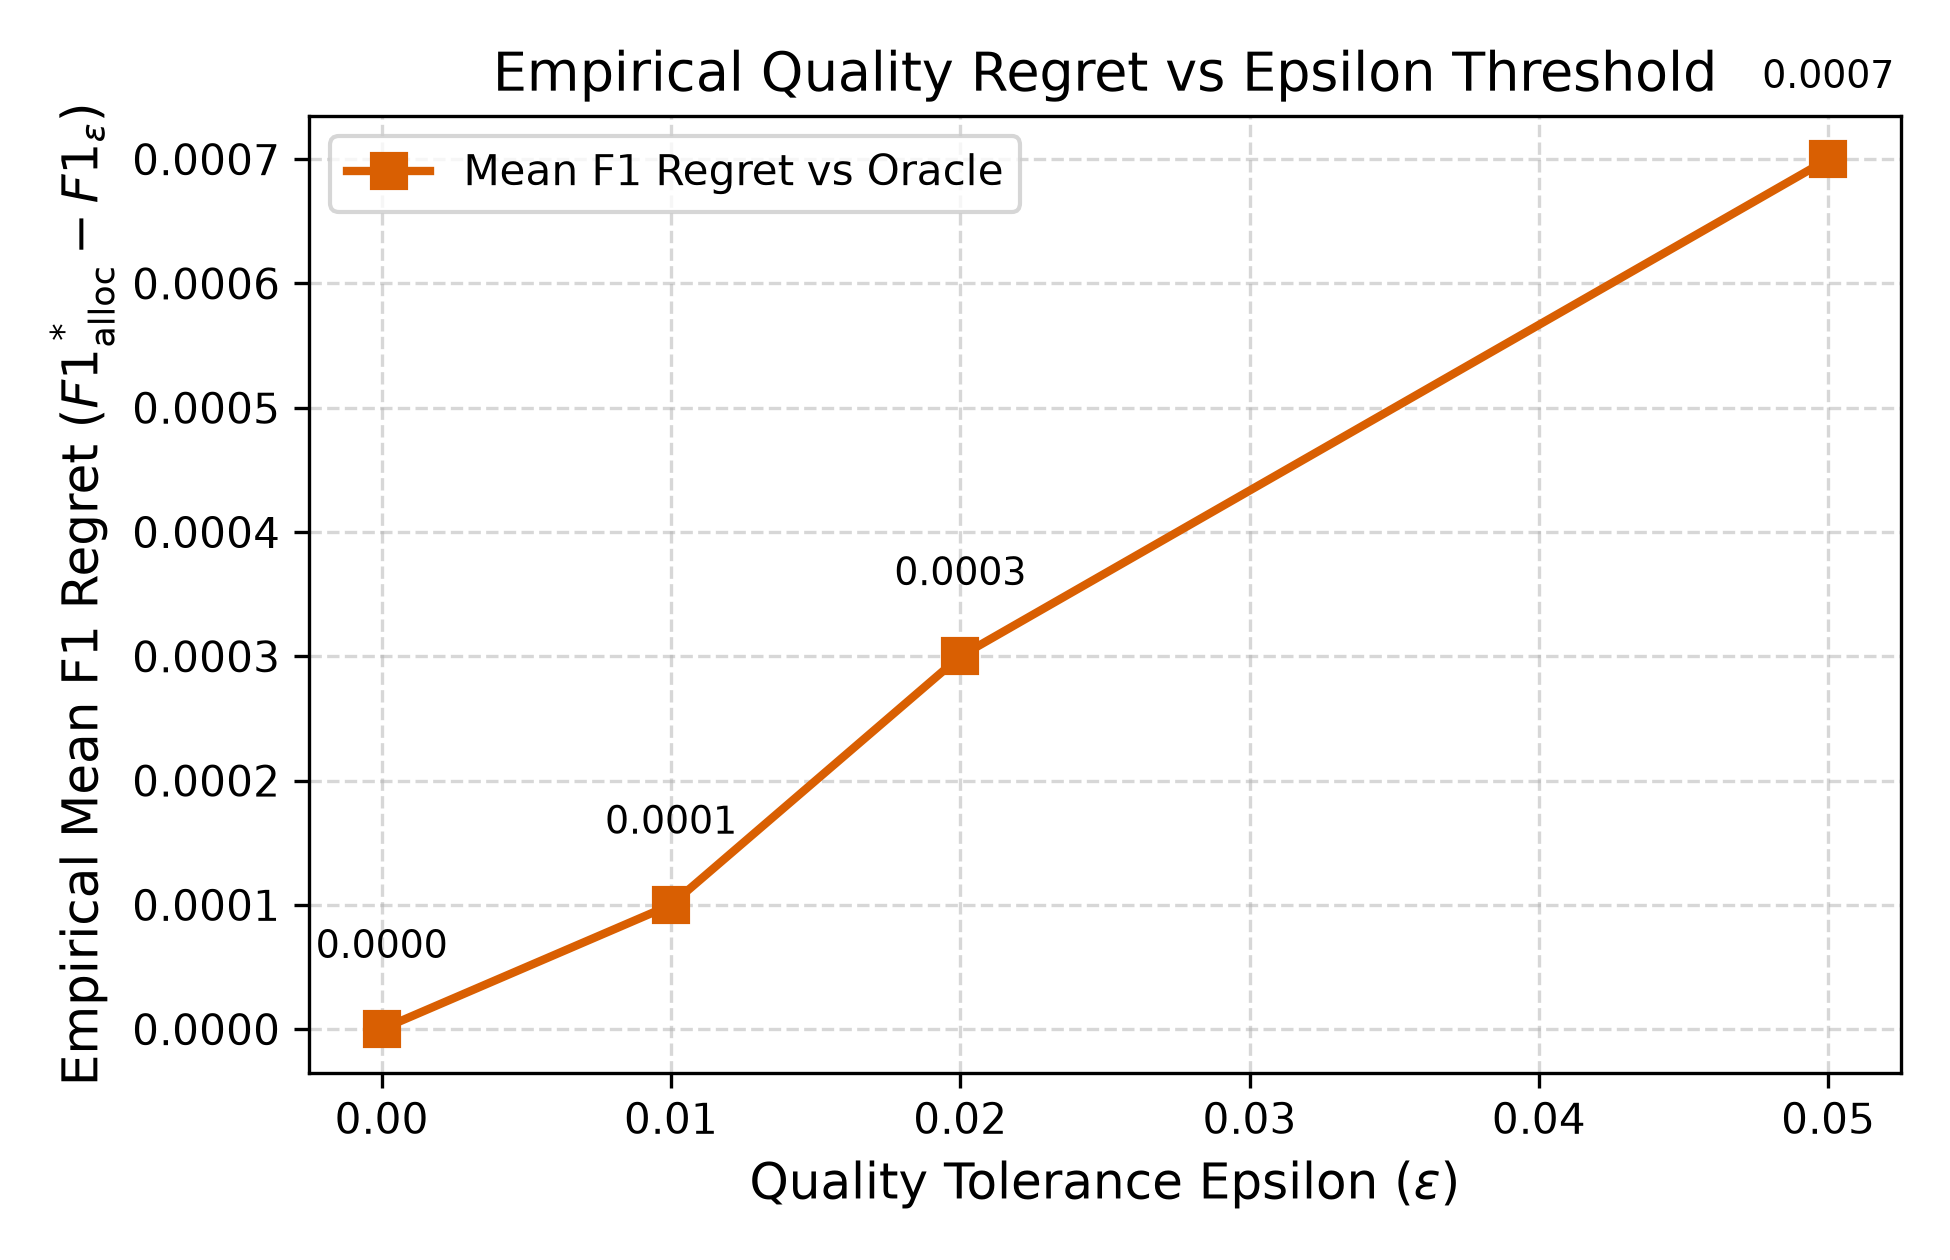

In [8]:
from src.week3.epsilon_analysis import run_epsilon_analysis

df_all_eps, df_eps_summary, sel_eps = run_epsilon_analysis(
    config["paths"]["week2_raw_matrix"],
    "results/week3/processed",
    config["epsilon_candidates"]
)

print("Epsilon Target Sweep Summary:")
display(df_eps_summary)

print(f"\nFrozen Epsilon* Selection: epsilon* = {sel_eps['epsilon_star']}")
print(f"Selection Rule: {sel_eps['selection_rule']}")
print(f"Rationale: {sel_eps['rationale']}")

# Display Plots 4, 5, 6
display(Image("results/week3/plots/plot4_mean_f1_comparison.png"))
display(Image("results/week3/plots/plot5_epsilon_vs_mean_k.png"))
display(Image("results/week3/plots/plot6_epsilon_vs_mean_regret.png"))


## 9. Pre-generation Retrieval Feature Signals
Explore univariate associations between pre-generation retrieval features and optimal budgets/headroom.


2026-09-30 17:29:42,869 [INFO] Successfully aligned 231 questions across features and targets.


2026-09-30 17:29:42,944 [INFO] Saved feature signal analysis table to results/week3/processed/feature_signal_analysis.csv


2026-09-30 17:29:42,947 [INFO] Saved feature signal summary to results/week3/processed/feature_signal_summary.json


Feature Signal Association Table:


,feature,target,spearman_rho,spearman_p,effect_size,interpretation
0,rho_1,best_k_qual,0.0518,0.4336,Negligible,"Spearman rho=0.052 (p=4.336e-01), KW H=2.98 (p..."
1,rho_1,selected_k_epsilon,0.0490,0.4582,Negligible,"Spearman rho=0.049 (p=4.582e-01), KW H=2.87 (p..."
2,rho_1,oracle_gain,-0.0435,0.5110,Negligible,"Spearman rho=-0.043 (p=5.110e-01), Pearson r=-..."
3,rho_1,f1_range,0.0209,0.7526,Negligible,"Spearman rho=0.021 (p=7.526e-01), Pearson r=-0..."
4,delta_12,best_k_qual,0.1320,0.0450,Weak,"Spearman rho=0.132 (p=4.498e-02), KW H=4.37 (p..."
5,delta_12,selected_k_epsilon,0.1260,0.0559,Weak,"Spearman rho=0.126 (p=5.586e-02), KW H=4.53 (p..."
6,delta_12,oracle_gain,0.0295,0.6554,Negligible,"Spearman rho=0.030 (p=6.554e-01), Pearson r=-0..."
7,delta_12,f1_range,0.0443,0.5025,Negligible,"Spearman rho=0.044 (p=5.025e-01), Pearson r=-0..."
8,entropy,best_k_qual,0.0532,0.4210,Negligible,"Spearman rho=0.053 (p=4.210e-01), KW H=3.25 (p..."
9,entropy,selected_k_epsilon,0.0479,0.4686,Negligible,"Spearman rho=0.048 (p=4.686e-01), KW H=2.98 (p..."


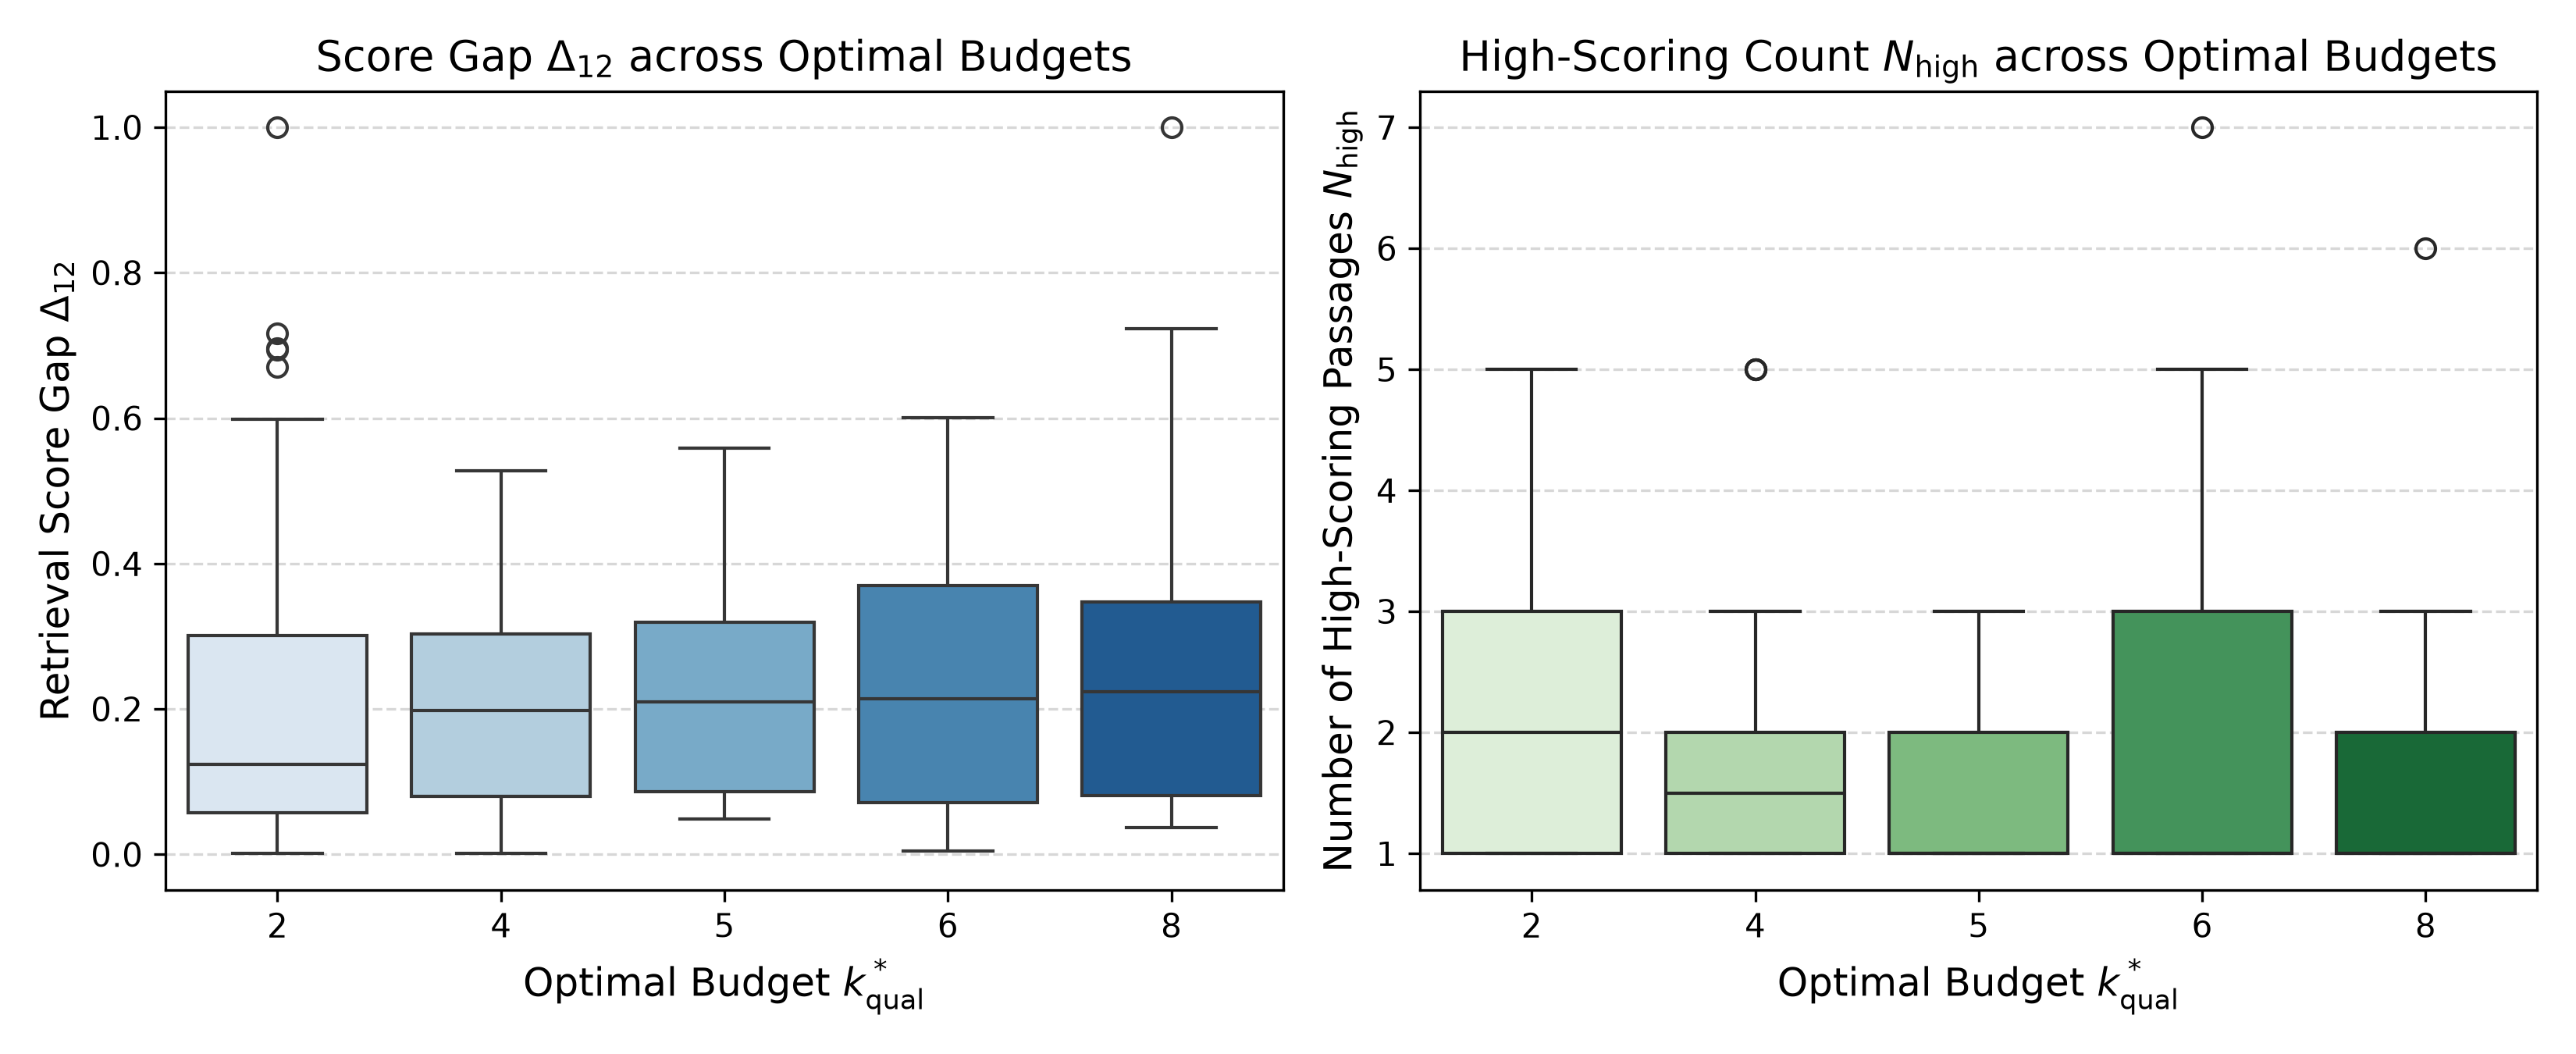

In [9]:
from src.week3.feature_signal_analysis import run_feature_signal_analysis

df_feat_rep, feat_summary = run_feature_signal_analysis(
    config["paths"]["week2_features"],
    "results/week3/processed/dev_quality_oracle.csv",
    "results/week3/processed/epsilon_oracle_all.csv",
    "results/week3/processed/per_query_heterogeneity.csv",
    "results/week3/processed",
    selected_eps=sel_eps["epsilon_star"]
)

print("Feature Signal Association Table:")
display(df_feat_rep[["feature", "target", "spearman_rho", "spearman_p", "effect_size", "interpretation"]])

# Display Plot 7
display(Image("results/week3/plots/plot7_feature_vs_oracle_k.png"))


## 10. Blinded 50-Question Human Audit Protocol
Inspect the blinded audit manifest ($N=50$ queries across $k \in \{2, 5, 10\}$), anonymized system outputs, and scoring template.
In accordance with project integrity guidelines, no synthetic scores are reported. The human evaluation is documented as pending manual scoring.


2026-09-30 17:29:43,004 [INFO] Saved audit sample manifest to results/week3/human_audit/audit_sample.csv


2026-09-30 17:29:43,077 [INFO] Saved secret blinding map to results/week3/human_audit/blinding_map.json


2026-09-30 17:29:43,079 [INFO] Saved ready-to-score template to results/week3/human_audit/human_scoring_template.csv (150 items awaiting evaluation)


2026-09-30 17:29:43,079 [INFO] Human scores file results/week3/human_audit/human_scores.csv does not exist; marking as PENDING_MANUAL_EVALUATION.


2026-09-30 17:29:43,080 [INFO] Saved human audit markdown report to results/week3/human_audit/human_audit_report.md (status: PENDING_MANUAL_EVALUATION)


Human Audit Status: PENDING_MANUAL_EVALUATION
Summary: Blinded evaluation sheet generated at human_scoring_template.csv. Human evaluation pending manual scoring.

Ready-to-Score Evaluator Artifact (150 judgments awaiting manual evaluation):


,audit_id,question_id,anonymous_system_id,question_text,generated_answer,score_0_1_2
0,1,1002,System A,How have the differences in communication styl...,The differences in communication styles betwee...,NaN
1,2,1002,System B,How have the differences in communication styl...,The differences in communication styles betwee...,NaN
2,3,1002,System C,How have the differences in communication styl...,The differences in communication styles betwee...,NaN
3,4,1004,System A,What is the baseline?,The two baselines are Majority Class baseline ...,NaN
4,5,1004,System B,What is the baseline?,LSTM baseline,NaN
5,6,1004,System C,What is the baseline?,Naive Bayes classifier,NaN


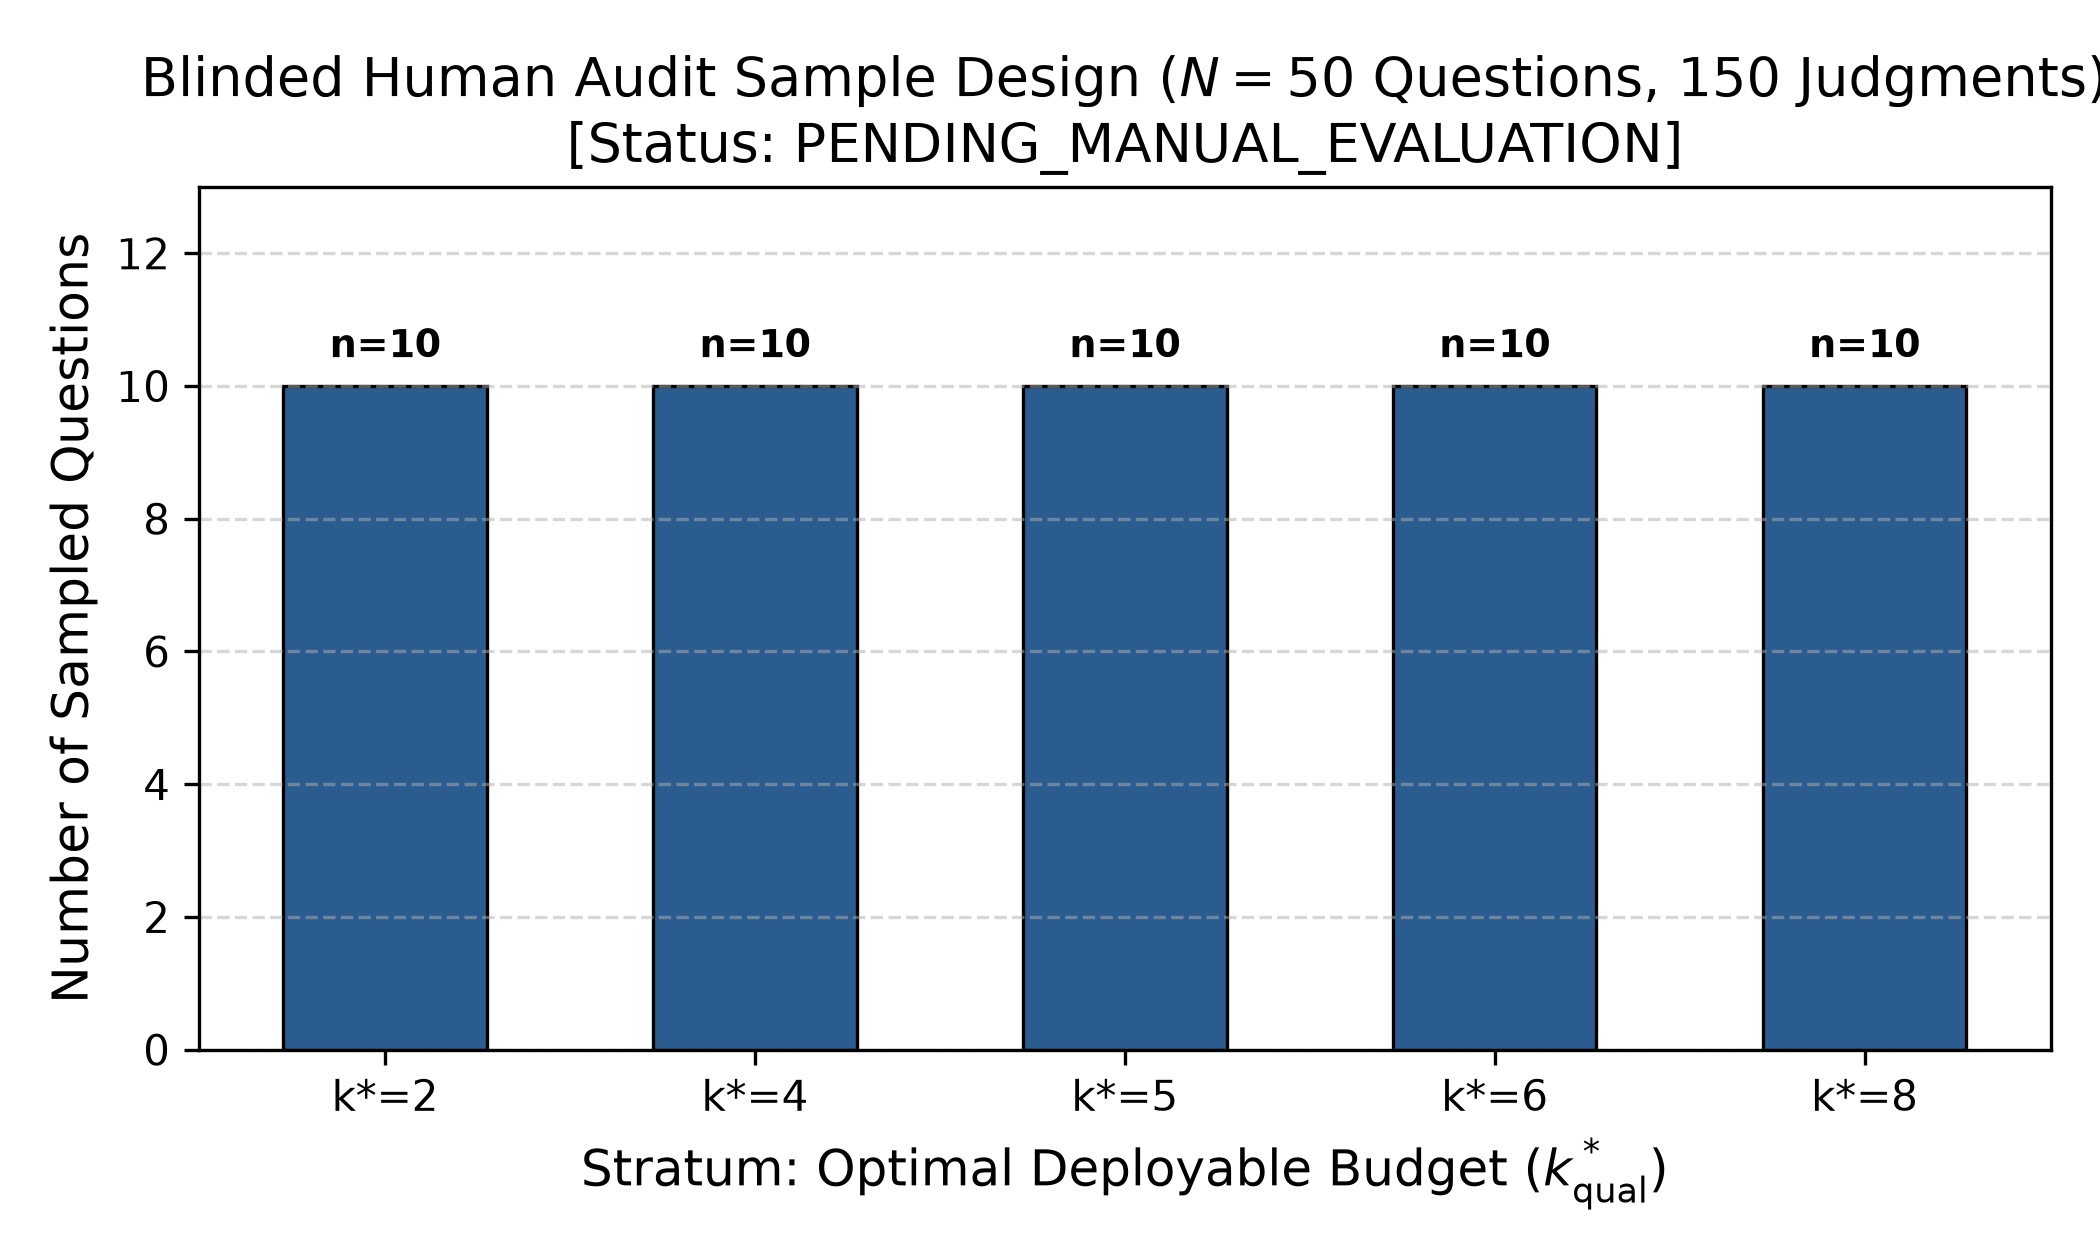

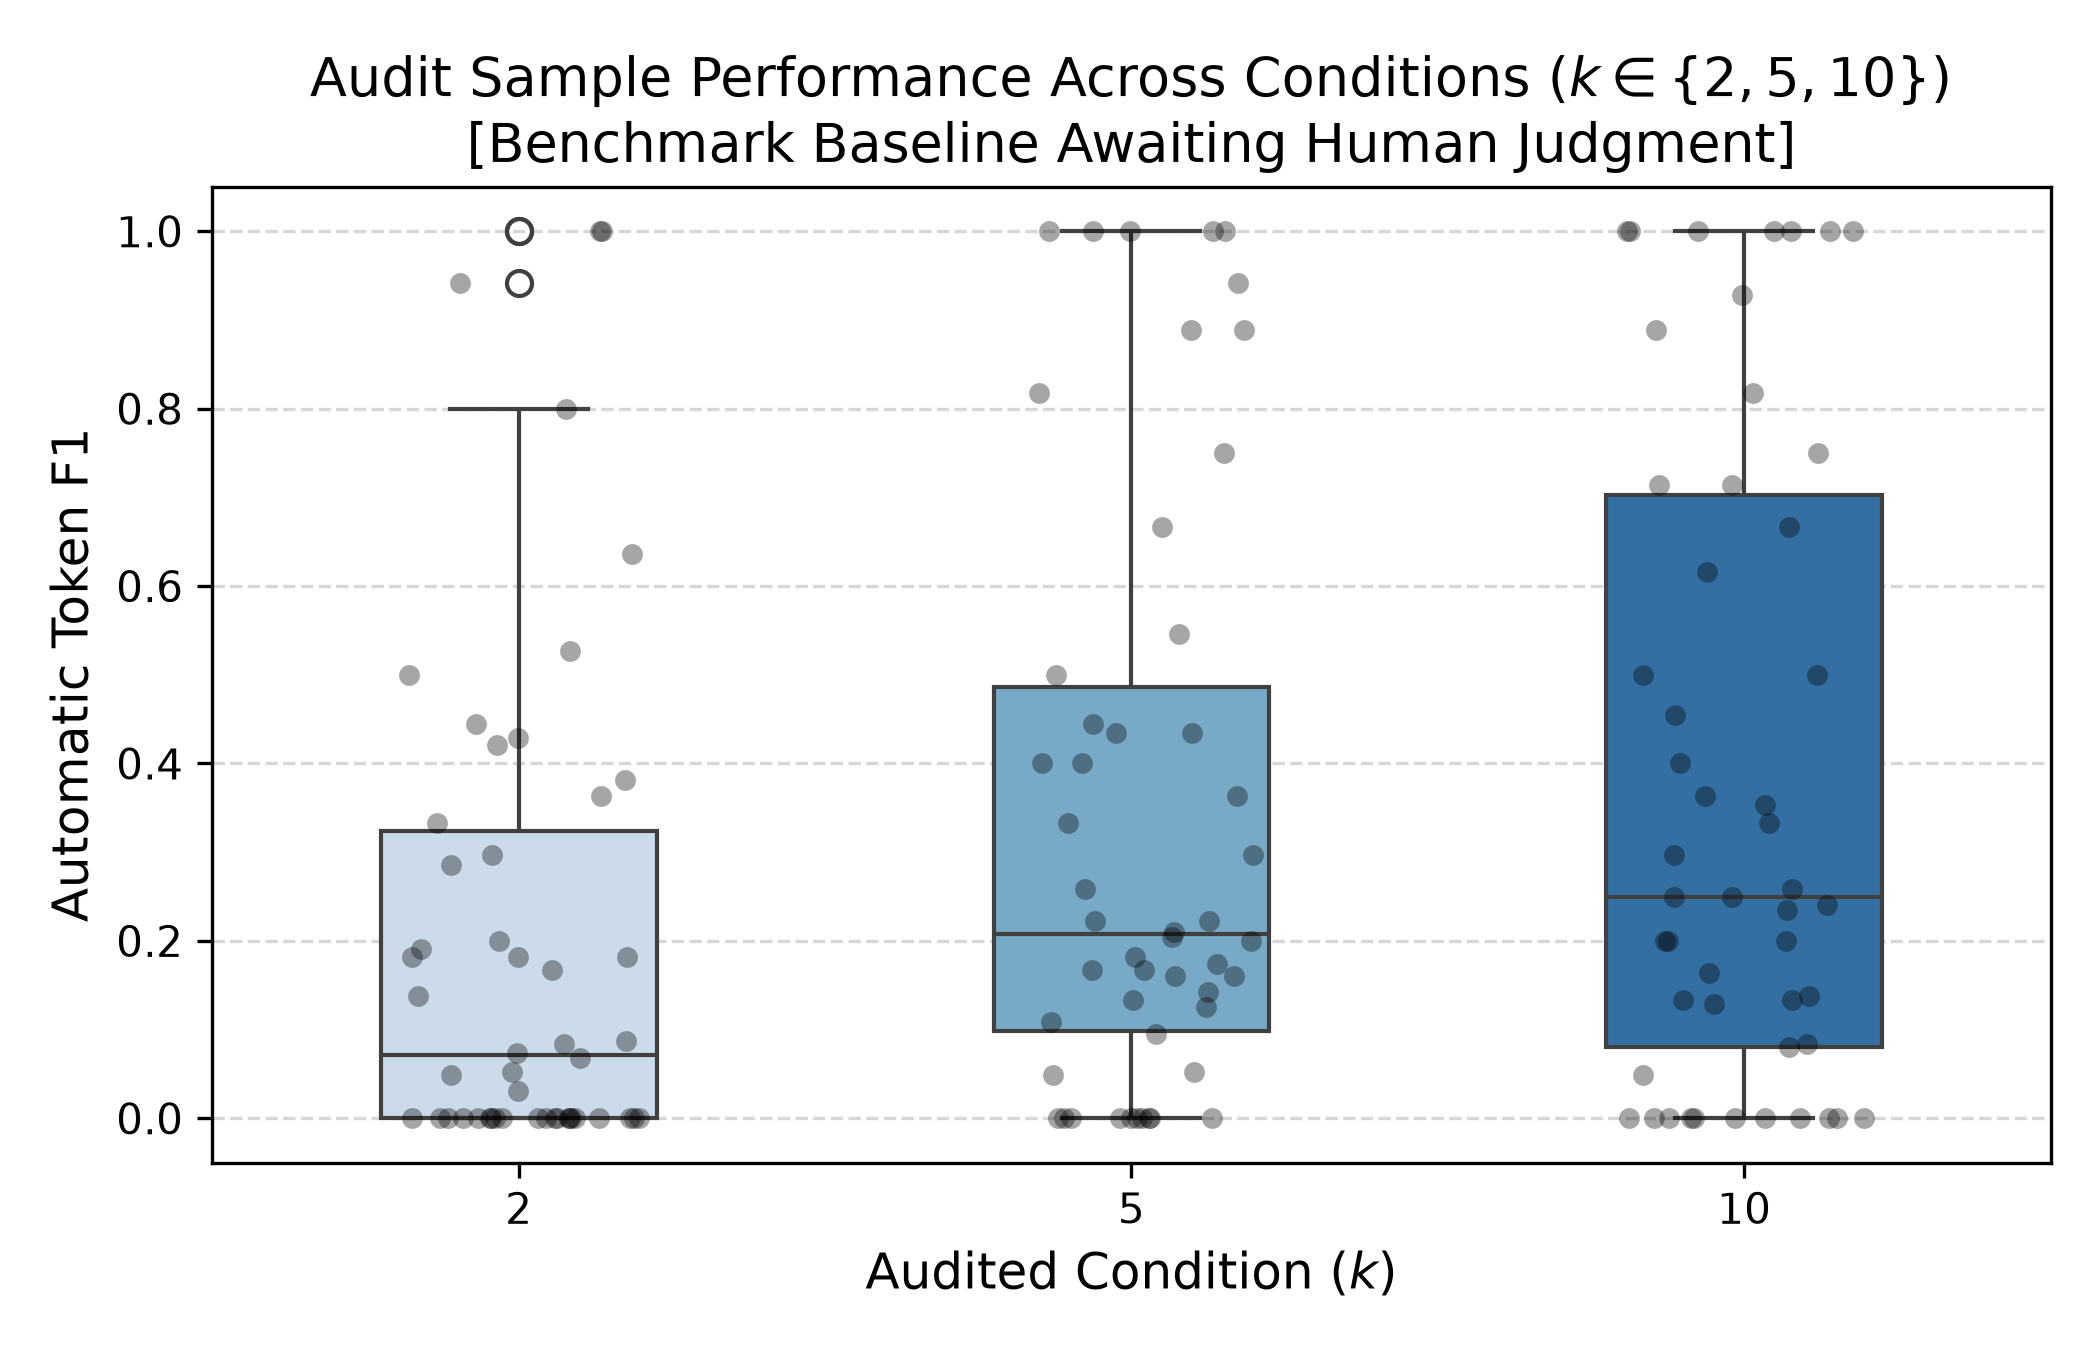

In [10]:
from src.week3.human_audit import run_human_audit

df_sample, status, df_k_sum, human_summary = run_human_audit(
    config["paths"]["week2_raw_matrix"],
    "results/week3/processed/dev_quality_oracle.csv",
    "results/week2/raw/dev_retrieval.jsonl",
    "results/week3/human_audit",
    n_sample=config["human_audit"]["n_questions"],
    seed=config["human_audit"]["random_seed"]
)

print(f"Human Audit Status: {status}")
print(f"Summary: {human_summary['message']}")

df_template = pd.read_csv("results/week3/human_audit/human_scoring_template.csv")
print(f"\nReady-to-Score Evaluator Artifact ({len(df_template)} judgments awaiting manual evaluation):")
display(df_template[["audit_id", "question_id", "anonymous_system_id", "question_text", "generated_answer", "score_0_1_2"]].head(6))

# Display Plots 8 & 9 (Audit Design & Baseline Performance)
display(Image("results/week3/plots/plot8_human_audit_design.png"))
display(Image("results/week3/plots/plot9_token_f1_by_audit_condition.png"))


## 11. Final Week-3 Scientific Summary & Go / No-Go Gate
Review the Week-3 decision gate and readiness for Week 4.


In [11]:
with open("results/week3/processed/week3_gate.json") as f:
    gate_data = json.load(f)

gate_df = pd.DataFrame([
    {"Dimension": "H1 Hypothesis Status", "Result": gate_data["H1_status"], "Assessment": gate_data["H1_rationale"][:90] + "..."},
    {"Dimension": "Epsilon Target Status", "Result": gate_data["epsilon_target_status"], "Assessment": gate_data["epsilon_target_rationale"][:90] + "..."},
    {"Dimension": "Feature Signal Status", "Result": gate_data["feature_signal_status"], "Assessment": gate_data["feature_signal_rationale"][:90] + "..."},
    {"Dimension": "Human Audit Status", "Result": gate_data["human_audit_status"], "Assessment": gate_data["human_audit_rationale"][:90] + "..."},
    {"Dimension": "Methodology Blockers", "Result": gate_data["methodology_blockers"], "Assessment": "Zero unresolved blockers"},
    {"Dimension": "Week 4 Readiness", "Result": gate_data["week4_readiness"], "Assessment": "Proceed to QCCA Allocator Training"}
])
display(gate_df)
print(f"\nWeek 3 Complete. Gate Status: {gate_data['week4_readiness']}")


,Dimension,Result,Assessment
0,H1 Hypothesis Status,SUPPORTED,Evidence requirements vary across queries: und...
1,Epsilon Target Status,SUPPORTED,SARA-internal target formulation guarantees 10...
2,Feature Signal Status,SUPPORTED,"Retrieval score gap delta_12 (rho=+0.132, p=0...."
3,Human Audit Status,PENDING_MANUAL_EVALUATION,Blinded evaluation design completed (50 questi...
4,Methodology Blockers,NONE,Zero unresolved blockers
5,Week 4 Readiness,READY (Oracle & Target Analysis Complete; Huma...,Proceed to QCCA Allocator Training



Week 3 Complete. Gate Status: READY (Oracle & Target Analysis Complete; Human Validation Pending Manual Evaluation)
